# Overfitting and Underfitting 🌸
### Understanding the Most Important Trade-off in Machine Learning (Iris Dataset)

Every model you train has to balance two failure modes:

- **Underfitting** — the model is too simple; it fails to capture real patterns (bad on both training AND test data)
- **Overfitting** — the model is too complex; it memorizes the training data instead of learning general patterns
  (great on training data, but bad on new/test data)

Our goal is always to land in the middle: a model that **generalizes well** to new data it hasn't seen.

We'll demonstrate this concretely using two models: **Decision Trees** and **K-Nearest Neighbors (KNN)**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 105, Test size: 45


## The Key Idea: Compare Training Accuracy vs. Test Accuracy

The trick to *spotting* overfitting or underfitting is simple: train the model, then check its accuracy
on **both** the training data AND the test data, and compare them.

| Situation | Training Accuracy | Test Accuracy | Diagnosis |
|---|---|---|---|
| Both low | Low | Low | **Underfitting** |
| Training much higher than test | High | Much lower | **Overfitting** |
| Both high and close together | High | High | **Good fit** ✅ |


## Demonstration 1: Decision Tree Depth

A Decision Tree's `max_depth` controls how many questions it's allowed to ask before making a decision.
- **Very shallow tree (e.g. depth=1)** → too simple → likely to **underfit**
- **Very deep tree (unlimited depth)** → memorizes training data → likely to **overfit**

Let's test a range of depths and plot both training and test accuracy.


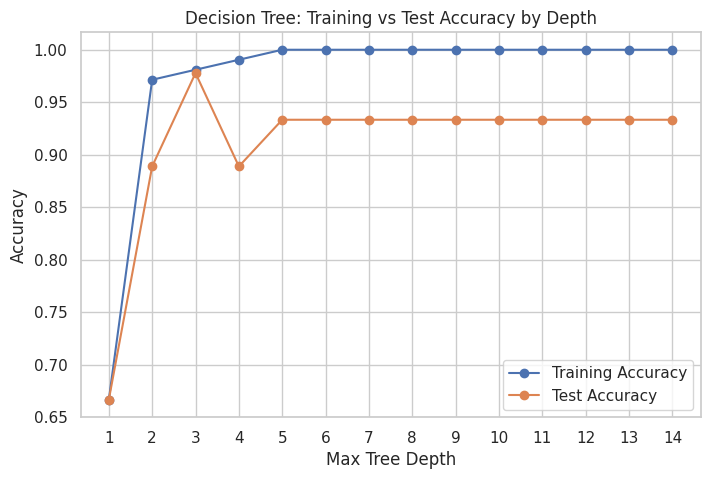

In [2]:
depths = range(1, 15)
train_acc = []
test_acc = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Training vs Test Accuracy by Depth')
plt.legend()
plt.xticks(list(depths))
plt.show()


**What to look for in the plot:**
- At **depth = 1**, both lines are relatively low → the tree is too simple → **underfitting**.
- As depth increases, training accuracy climbs toward 100% and test accuracy plateaus or even dips slightly →
  the tree is starting to memorize quirks of the training set → early signs of **overfitting**.
- The best depth is usually where **test accuracy is highest and the two lines are still close together** —
  not necessarily where training accuracy is highest!

This gap between training and test accuracy is the single most important thing to watch for in ML.


## Demonstration 2: KNN and the Number of Neighbors (K)

For KNN, the roles are flipped compared to tree depth:
- **Very small K (e.g. K=1)** → the model reacts to every single nearby point, including noise → **overfitting**
- **Very large K** → the model averages over too many neighbors and loses local detail → **underfitting**


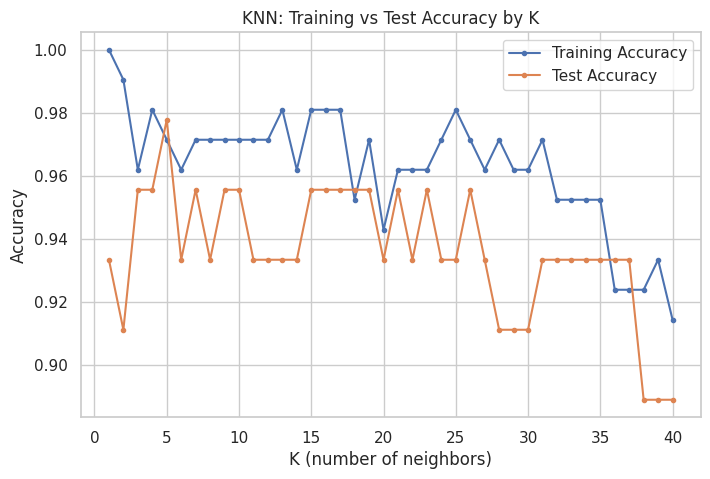

In [3]:
k_values = range(1, 41)
train_acc_knn = []
test_acc_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc_knn.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc_knn.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), train_acc_knn, marker='.', label='Training Accuracy')
plt.plot(list(k_values), test_acc_knn, marker='.', label='Test Accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy by K')
plt.legend()
plt.show()


**What to look for:**
- At **K = 1**, training accuracy is at (or near) 100% — the model perfectly "remembers" every training point —
  but test accuracy is noticeably lower. This gap **is** overfitting.
- As K increases, the two lines converge — the model generalizes better.
- If K gets *too* large, both training and test accuracy start to drop together — that's **underfitting**,
  because the model is now too simple/smoothed-out to capture real distinctions between species.


## Visualizing Overfitting Directly: Decision Boundaries

Let's make this even more visual. We'll train Decision Trees using only 2 features (for plotting purposes)
at different depths, and literally draw the regions each model assigns to each species.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


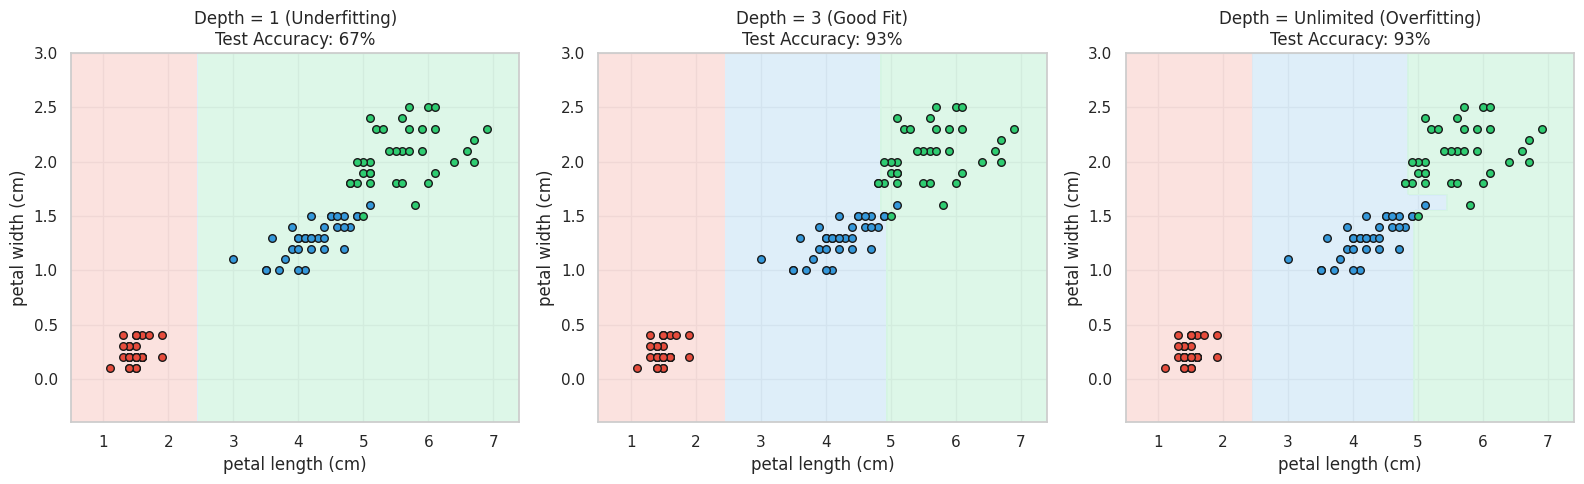

In [4]:
from matplotlib.colors import ListedColormap

# Use only 2 features so we can plot a 2D decision boundary
feature_x, feature_y = 'petal length (cm)', 'petal width (cm)'
X2 = X[[feature_x, feature_y]]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
depths_to_show = [1, 3, None]  # None = unlimited depth
titles = ['Depth = 1 (Underfitting)', 'Depth = 3 (Good Fit)', 'Depth = Unlimited (Overfitting)']
cmap_light = ListedColormap(['#FADBD8', '#D6EAF8', '#D5F5E3'])
cmap_bold = ['#E74C3C', '#3498DB', '#2ECC71']

for ax, depth, title in zip(axes, depths_to_show, titles):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X2_train, y2_train)

    # Build a grid to color in each region's predicted class
    x_min, x_max = X2[feature_x].min() - 0.5, X2[feature_x].max() + 0.5
    y_min, y_max = X2[feature_y].min() - 0.5, X2[feature_y].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    for cls in [0, 1, 2]:
        subset = X2_train[y2_train == cls]
        ax.scatter(subset[feature_x], subset[feature_y], c=cmap_bold[cls], edgecolor='k', s=30)

    test_acc_val = accuracy_score(y2_test, tree.predict(X2_test))
    ax.set_title(f"{title}\nTest Accuracy: {test_acc_val:.0%}")
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)

plt.tight_layout()
plt.show()


**What you're looking at:** each colored region shows what species the model would predict in that area.

- **Depth = 1**: only ONE dividing line — way too simple, it can't separate versicolor from virginica at all. **Underfitting**.
- **Depth = 3**: clean, sensible regions that roughly match the natural clusters. **Good fit**.
- **Unlimited depth**: jagged, oddly-shaped little pockets carved out to perfectly match individual training points —
  this is the visual signature of **overfitting**. The model has memorized noise instead of learning the real boundary.


## How Do We Fix Overfitting and Underfitting?

**If underfitting (model too simple):**
- Use a more complex/flexible model, or increase model capacity (e.g. deeper tree, smaller K)
- Add more relevant features
- Train longer / reduce regularization

**If overfitting (model too complex):**
- Simplify the model (shallower tree, larger K)
- Get more training data
- Use regularization techniques
- Use cross-validation to pick hyperparameters more reliably (more on this in the Training/Testing/Evaluation notebook!)


## Recap

| Concept | Symptom | Fix Direction |
|---|---|---|
| **Underfitting** | Low accuracy on both train & test | Increase model complexity |
| **Overfitting** | High train accuracy, much lower test accuracy | Decrease model complexity / get more data |
| **Good fit** | High and similar accuracy on both | 🎯 This is the goal |

The core skill isn't memorizing which knob to turn — it's **noticing the gap between training and test performance**
and reasoning about which direction to adjust.

---

## 🧪 Try It Yourself

1. Change `test_size` to `0.5` in the first split — does the overfitting pattern in the Decision Tree plot get worse or better?
2. In the KNN plot, find the K value where test accuracy is highest. Is training accuracy also at its highest there?
3. Try the decision boundary plot with two different features (e.g. `sepal length (cm)` and `sepal width (cm)`) —
   is the overfitting pattern at unlimited depth still as visible? Why might that be different?
4. (Challenge) Look up `DecisionTreeClassifier(min_samples_leaf=...)` — try setting it to `10` at unlimited depth.
   Does it reduce overfitting without manually limiting `max_depth`?
